# Joint stratification (severity × geography) — Flood

Third stratification candidate for the dev (non-OOD) train/val/test split, alongside a
severity-quantile split and a grid-based split (see `stratification_by_grid.ipynb`). All three
methods are computed **inline in this notebook** from the raw chip-level manifest — none of them
are read off a pre-existing `split`/`severity_ivw` column in the production manifest, so this
notebook runs the same way regardless of whether `update_split.py` has already been run for this
hazard. (It hadn't been, for Flood, at the time this was written — see the Method A cell
for a cross-check against the production manifest when that column *does* already exist, e.g. for
Burnt.)

Each single-axis method wins its own axis by leaving the *other* axis to chance. **Method C (joint)**
crosses severity-quantile bins with a *coarse* geography bucket (continent, with sparse continents
folded into "Other" so no cell degenerates to 1–2 events) — deliberately coarse, because fine grid
cells (Method B) are small enough that spreading a cell's few events across train/val/test risks
putting spatially-adjacent events in different splits, which is the autocorrelation-leakage failure
mode Kattenborn et al. 2022 measured inflating scores up to 28%; continents are large enough that
within-bucket event pairs aren't the near-neighbor pairs that concern is actually about.

As always: the cross-region **OOD hold-out is unchanged/reused**, carved out before any
train/val/test split.

**Note on Flood specifically:** the production manifest at `AgDamage_Benchmark_v2/Flooded/manifest.parquet` does not yet carry `severity_ivw`/`split` columns — `update_split.py --reshard` *has* been run for Flood, but its output only ever landed in the sibling `AgDamage_Benchmark_v2_resharded/Flooded/` directory (that script never writes into `--root` itself), and nobody has promoted it back to the main location the way Burnt's was. This notebook doesn't depend on that either way.

In [1]:
# ============================== CONFIG (edit) ==============================
from pathlib import Path
INPUT_PATHS       = ["/fs/ess/PGS0413/AgDamage_Benchmark_v2/Flooded/manifest.parquet"]
OUTPUT_DIR        = "out/stratification_by_joint_flooded"

RATIOS            = (0.6, 0.2, 0.2)     # train : val : test (events, on the non-OOD remainder)
SEED              = 42

DEFAULT_SIZE      = 512
MIN_CROPLAND_FRAC = 0.0
SEVERITY_COL      = "severity_ivw"
K                 = 4          # severity quantile bins, same as the production severity-quantile split

# --- cross-region OOD hold-out: already decided, reused as-is ---
OOD_UNIT          = "country"
OOD_REGIONS       = {"flooded": ["Philippines"]}

# --- joint-stratification knobs (Method C) ---
GEO_UNIT          = "continent"
GEO_MIN_EVENTS    = 30    # geo units with fewer dev events than this get folded into a single "Other" bucket

# --- grid knobs (Method B, recomputed inline here only for the 3-way comparison) ---
GRID_SIZE_DEG        = 10.0
MIN_EVENTS_PER_CELL  = 15

SEVERITY_FIELD_BY_HAZARD = {
    "flood": "flooded_crop_frac", "flooded": "flooded_crop_frac",
    "burnt": "burned_crop_frac", "burned": "burned_crop_frac", "fire": "burned_crop_frac",
}

In [2]:
import numpy as np, pandas as pd, matplotlib.pyplot as plt
Path(OUTPUT_DIR).mkdir(parents=True, exist_ok=True)

def _read(p):
    p = str(p); return pd.read_parquet(p) if p.endswith((".parquet", ".pq")) else pd.read_csv(p)

df = pd.concat([_read(p) for p in INPUT_PATHS], ignore_index=True)
print(f"Loaded {len(df):,} chips | {df['event_id'].nunique():,} events | hazards: {sorted(df['hazard'].dropna().unique())}")
df.head()

Loaded 5,102 chips | 1,297 events | hazards: ['Flooded']


,chip_id,event_id,rank,source,tier,continent,country,place,event_date_start,event_date_end,...,flood_persistence_mean,min_lon,min_lat,max_lon,max_lat,hazard,shard,has_s1,phenology_stage,qc_verdict
0,DFO4839_r1536_c3072,DFO4839,0,dfo,C,SouthAmerica,Peru,Peru,2020-01-01,2020-01-08,...,23.9,-76.515146,-7.114473,-76.468648,-7.068024,Flooded,flooded-000271.tar,True,dormant,clean
1,DFO4839_r2560_c3072,DFO4839,1,dfo,C,SouthAmerica,Peru,Peru,2020-01-01,2020-01-08,...,22.5,-76.515451,-7.207072,-76.468943,-7.160622,Flooded,flooded-000162.tar,True,dormant,clean
2,DFO4898_r21504_c27648,DFO4898,0,dfo,C,SouthAmerica,Peru,Peru,2020-03-28,2020-04-02,...,38.2,-76.345591,-6.941636,-76.299127,-6.895204,Flooded,flooded-000313.tar,True,dormant,s1_unusable
3,DFO4898_r23040_c26112,DFO4898,1,dfo,C,SouthAmerica,Peru,Peru,2020-03-28,2020-04-02,...,29.0,-76.485037,-7.080137,-76.438546,-7.033692,Flooded,flooded-000165.tar,True,dormant,s2_unusable
4,DFO4898_r23552_c25600,DFO4898,2,dfo,C,SouthAmerica,Peru,Peru,2020-03-28,2020-04-02,...,31.4,-76.531537,-7.126291,-76.485037,-7.079841,Flooded,flooded-000104.tar,True,dormant,s2_unusable


## Infer missing `country` for `groundsource` chips (offline reverse geocoding)

Essential here whenever `country` is sparsely populated for this hazard's `groundsource` chips
(e.g. Flood: ~8% populated) — the OOD carve below matches on `country`, so without this inference
step a real region can silently match 0 events instead of carving the intended hold-out. No-op
when `country` is already complete (e.g. Burnt: 100%).

In [3]:
import geopandas as gpd
NE_COUNTRIES_SHP = "naturalearth/ne_50m_admin_0_countries.shp"

def infer_country_from_latlon(df, shp_path=NE_COUNTRIES_SHP):
    df = df.copy()
    need = df["country"].isna() & (df.get("source") == "groundsource")
    if "centroid_lon" in df.columns:
        clon, clat = df["centroid_lon"], df["centroid_lat"]
    else:
        clon, clat = (df["min_lon"] + df["max_lon"]) / 2, (df["min_lat"] + df["max_lat"]) / 2
    need &= clon.notna() & clat.notna()
    df["country_inferred"] = False
    if not need.any():
        return df
    countries = gpd.read_file(shp_path)[["NAME", "CONTINENT", "geometry"]]
    pts = gpd.GeoDataFrame({"idx": df.index[need]}, geometry=gpd.points_from_xy(clon[need], clat[need]), crs="EPSG:4326")
    joined = gpd.sjoin(pts, countries, how="left", predicate="within").drop_duplicates("idx").set_index("idx")
    unmatched = joined[joined["NAME"].isna()]
    if len(unmatched):
        pts_m = pts.set_index("idx").to_crs(3857)
        countries_m = countries.to_crs(3857)
        nearest = gpd.sjoin_nearest(pts_m.loc[unmatched.index, ["geometry"]], countries_m, how="left")
        nearest = nearest[~nearest.index.duplicated(keep="first")]
        joined.loc[nearest.index, "NAME"] = nearest["NAME"]
    df.loc[joined.index, "country"] = joined["NAME"]
    df.loc[joined.index, "country_inferred"] = joined["NAME"].notna()
    return df

df = infer_country_from_latlon(df)
n_inferred = int(df["country_inferred"].sum())
print(f"Inferred country for {n_inferred:,} groundsource chips from lat/lon; "
      f"{int(df['country'].isna().sum()):,} chips still have no country.")

Inferred country for 4,709 groundsource chips from lat/lon; 0 chips still have no country.


## Event-level severity + centroid

In [4]:
def resolve_damage_frac(row):
    if "damage_frac" in df.columns and pd.notna(row.get("damage_frac")): return row["damage_frac"]
    fld = SEVERITY_FIELD_BY_HAZARD.get(str(row["hazard"]).lower())
    if fld and fld in df.columns and pd.notna(row.get(fld)): return row[fld]
    for f in ("flooded_crop_frac", "burned_crop_frac", "damaged_crop_frac"):
        if f in df.columns and pd.notna(row.get(f)): return row[f]
    return np.nan

df["damage_frac"] = df.apply(resolve_damage_frac, axis=1).astype(float)
size = df["size"] if "size" in df.columns else DEFAULT_SIZE
df["cropland_px"] = (df["cropland_frac"].astype(float) * (np.asarray(size) ** 2)).round()
gated = df[df["cropland_frac"].astype(float) >= MIN_CROPLAND_FRAC].copy()
print(f"Gate MIN_CROPLAND_FRAC={MIN_CROPLAND_FRAC}: kept {len(gated):,}/{len(df):,} chips")

g = gated.dropna(subset=["damage_frac"]).copy()
g["w"] = g["cropland_px"].clip(lower=0); g["wf"] = g["w"] * g["damage_frac"]
if "centroid_lon" not in g.columns and {"min_lon", "max_lon"} <= set(g.columns):
    g["centroid_lon"] = (g["min_lon"] + g["max_lon"]) / 2
    g["centroid_lat"] = (g["min_lat"] + g["max_lat"]) / 2
for c in ("centroid_lon", "centroid_lat"):
    if c not in g.columns: g[c] = np.nan
aggd = {"n_chips": ("damage_frac", "size"), "severity_mean": ("damage_frac", "mean"),
        "_ws": ("w", "sum"), "_wf": ("wf", "sum"),
        "centroid_lon": ("centroid_lon", "mean"), "centroid_lat": ("centroid_lat", "mean")}
for col in ("country", "continent"):
    if col in g.columns: aggd[col] = (col, "first")
events = g.groupby(["event_id", "hazard"], as_index=False).agg(**aggd)
events["severity_ivw"] = np.where(events["_ws"] > 0, events["_wf"] / events["_ws"], np.nan)
events = events.drop(columns=["_ws", "_wf"])
print(f"{len(events):,} events aggregated")
events.head()

Gate MIN_CROPLAND_FRAC=0.0: kept 5,102/5,102 chips
1,297 events aggregated


,event_id,hazard,n_chips,severity_mean,centroid_lon,centroid_lat,country,continent,severity_ivw
0,DFO4839,Flooded,2,0.02345,-76.492047,-7.137548,Peru,SouthAmerica,0.024046
1,DFO4898,Flooded,3,0.03430,-76.430813,-7.026134,Peru,SouthAmerica,0.032254
2,DFO4909,Flooded,5,0.05690,52.152345,31.625448,Iran (Islamic Republic of),MiddleEast,0.048847
3,DFO4934,Flooded,5,0.06316,104.818369,47.962654,Mongolia,EastAsia,0.062917
4,DFO4938,Flooded,5,0.43920,114.940053,31.529093,China,EastAsia,0.442025


## Cross-region OOD hold-out — reused, not recomputed

Raises rather than silently carving nothing if the requested region matches 0 events — a real
region can otherwise match 0 events with no error at all if `country` inference above didn't run
or didn't resolve it (exactly the failure mode `carve_ood()` in `repackage_agdamage.py` guards
against in production).

In [5]:
events["subset"] = "dev"
for hz, regs in (OOD_REGIONS or {}).items():
    if OOD_UNIT not in events.columns:
        raise ValueError(f"--ood-unit={OOD_UNIT!r} but events has no {OOD_UNIT!r} column")
    hz_mask = events["hazard"].astype(str).str.lower() == str(hz).lower()
    m = hz_mask & events[OOD_UNIT].isin(list(regs))
    if not m.any():
        available = sorted(events.loc[hz_mask, OOD_UNIT].dropna().unique().tolist())
        raise ValueError(
            f"OOD_REGIONS {regs!r} for hazard {hz!r} matched 0 of {int(hz_mask.sum())} events -- "
            f"refusing to silently carve nothing. Known {OOD_UNIT} values: {available[:40]}"
        )
    events.loc[m, "subset"] = "ood_holdout"
print(events.groupby(["hazard", "subset"]).size().to_string())

hazard   subset     
Flooded  dev            1276
         ood_holdout      21


## Method C — joint stratification: severity quantile × coarse geography

`build_geo_bucket` folds any `GEO_UNIT` (continent) value with fewer than `GEO_MIN_EVENTS` dev
events into a single `"Other"` pool. Crossing those buckets with `K=4` severity-quantile bins
gives the joint strata. Within each joint stratum, events are seeded-shuffled and ratio-sliced
into train/val/test — identical `_alloc` mechanics to the other methods, just keyed by
`(geo_bucket, sev_class)` instead of a single axis.

In [6]:
def build_geo_bucket(dev: pd.DataFrame, geo_unit: str, min_events: int) -> pd.Series:
    """Coarse geography bucket: geo_unit as-is, except units with fewer than
    min_events dev events get folded into a single 'Other' pool. Coarse on
    purpose -- continents are large enough that within-bucket event pairs
    aren't the near-neighbor pairs the spatial-autocorrelation-leakage
    concern (Kattenborn 2022) is actually about, unlike fine grid cells."""
    counts = dev[geo_unit].value_counts()
    small = counts[counts < min_events].index.tolist()
    return dev[geo_unit].where(~dev[geo_unit].isin(small), "Other")

def quantile_bins(s: pd.Series, k: int) -> pd.Series:
    return pd.qcut(s, k, labels=[f"q{i+1}" for i in range(k)], duplicates="drop").astype(object)

def _alloc(n, r):
    n_tr = int(round(n * r[0])); n_va = int(round(n * r[1])); n_te = n - n_tr - n_va
    if n_te < 0: n_va += n_te; n_te = 0
    return n_tr, n_va, n_te

dev_j = events[events["subset"] == "dev"].copy()
dev_j["geo_bucket"] = build_geo_bucket(dev_j, GEO_UNIT, GEO_MIN_EVENTS)
dev_j["sev_class"] = quantile_bins(dev_j[SEVERITY_COL], K)
dev_j["joint_stratum"] = dev_j["geo_bucket"].astype(str) + "_" + dev_j["sev_class"].astype(str)

strata_sizes = dev_j["joint_stratum"].value_counts().sort_values()
print(f"Joint strata: {dev_j['geo_bucket'].nunique()} geo buckets x {K} severity bins -> {len(strata_sizes)} joint strata")
print(strata_sizes.describe())

Joint strata: 8 geo buckets x 4 severity bins -> 32 joint strata
count     32.000000
mean      39.875000
std       40.109326
min        3.000000
25%       13.500000
50%       27.500000
75%       61.500000
max      195.000000
Name: count, dtype: float64


### Joint strata sizes — geo bucket × severity quantile

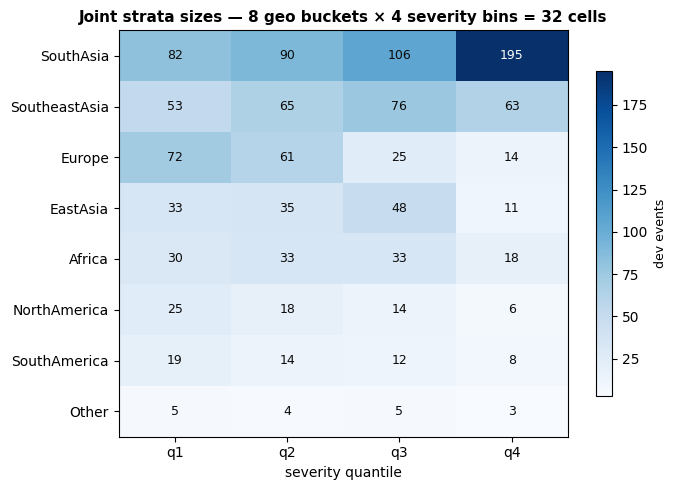

In [7]:
import geopandas as gpd
world = gpd.read_file(NE_COUNTRIES_SHP)

SPLIT_COLOR = {"train": "#2a78d6", "val": "#1baf7a", "test": "#eb6834"}
OOD_COLOR = "#52514e"
SEQ_BLUE = plt.get_cmap("Blues")
GEO_PALETTE = ["#0072B2", "#E69F00", "#009E73", "#D55E00", "#CC79A7", "#56B4E9", "#F0E442", "#999999"]  # Okabe-Ito (8 colors), colorblind-safe -- gray last, for an "Other" bucket

def basemap(ax):
    world.plot(ax=ax, color="#eeece6", edgecolor="white", linewidth=0.4, zorder=1)
    ax.set_xlim(-135, 155); ax.set_ylim(-45, 65)
    ax.set_xticks([]); ax.set_yticks([])
    for s in ax.spines.values(): s.set_visible(False)

pivot = dev_j.groupby(["geo_bucket", "sev_class"]).size().unstack(fill_value=0)
geo_order = dev_j.groupby("geo_bucket")["event_id"].size().sort_values(ascending=False).index
pivot = pivot.loc[geo_order, [f"q{i+1}" for i in range(K)]]

fig, ax = plt.subplots(figsize=(7, 5))
im = ax.imshow(pivot.values, cmap=SEQ_BLUE, aspect="auto")
ax.set_xticks(range(len(pivot.columns))); ax.set_xticklabels(pivot.columns)
ax.set_yticks(range(len(pivot.index))); ax.set_yticklabels(pivot.index)
for i in range(pivot.shape[0]):
    for j in range(pivot.shape[1]):
        v = pivot.values[i, j]
        ax.text(j, i, str(v), ha="center", va="center", fontsize=9,
                 color="white" if v > pivot.values.max() * 0.55 else "#0b0b0b")
ax.set_xlabel("severity quantile")
ax.set_title(f"Joint strata sizes \u2014 {pivot.shape[0]} geo buckets \u00d7 {K} severity bins = {pivot.size} cells", fontsize=11, fontweight="bold")
cbar = fig.colorbar(im, ax=ax, shrink=0.8); cbar.set_label("dev events", fontsize=9)
fig.tight_layout()
fig.savefig(f"{OUTPUT_DIR}/01_joint_strata_heatmap.png", dpi=200, bbox_inches="tight", facecolor="white")
plt.show()

### Where the geo buckets actually are

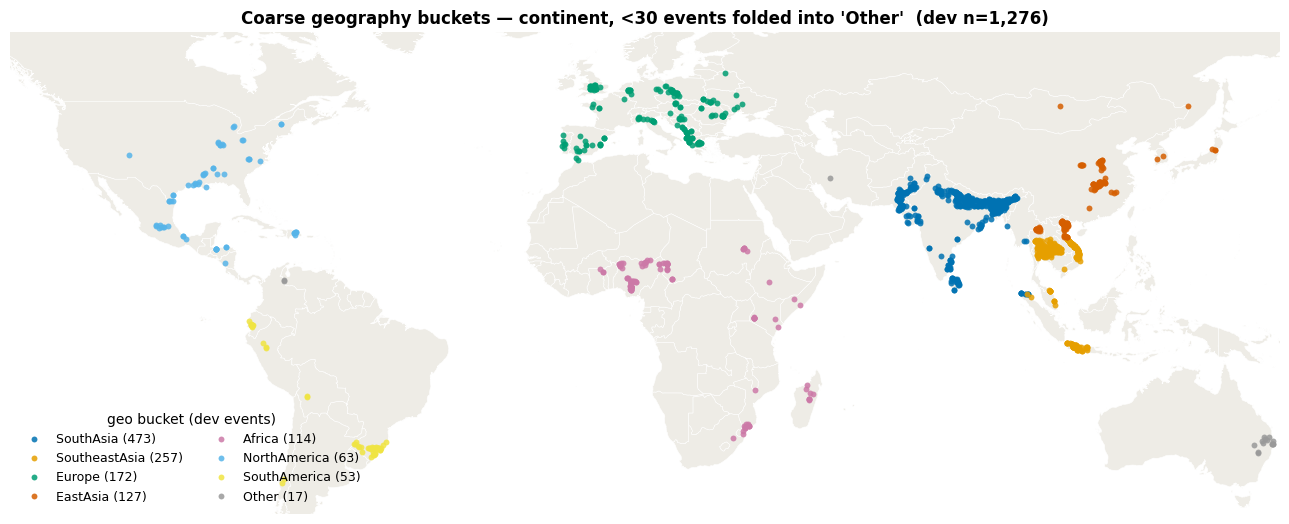

In [8]:
fig, ax = plt.subplots(figsize=(13, 6.5))
basemap(ax)
for i, gb in enumerate(geo_order):
    sub = dev_j[dev_j["geo_bucket"] == gb]
    ax.scatter(sub["centroid_lon"], sub["centroid_lat"], s=18, color=GEO_PALETTE[i % len(GEO_PALETTE)],
               alpha=0.85, linewidth=0, zorder=3, label=f"{gb} ({len(sub)})")
ax.legend(loc="lower left", frameon=False, fontsize=9, ncol=2, title="geo bucket (dev events)")
ax.set_title(f"Coarse geography buckets \u2014 {GEO_UNIT}, <{GEO_MIN_EVENTS} events folded into \'Other\'  (dev n={len(dev_j):,})",
             fontsize=12, fontweight="bold")
fig.tight_layout()
fig.savefig(f"{OUTPUT_DIR}/02_geo_buckets_map.png", dpi=200, bbox_inches="tight", facecolor="white")
plt.show()

## Split within each joint stratum, write the manifest, leakage check

In [9]:
rng = np.random.default_rng(SEED)
event_split_joint = {}
for cell, grp in dev_j.groupby("joint_stratum"):
    ids = grp["event_id"].tolist(); rng.shuffle(ids)
    n_tr, n_va, n_te = _alloc(len(ids), RATIOS)
    for i, e in enumerate(ids):
        event_split_joint[e] = "train" if i < n_tr else ("val" if i < n_tr + n_va else "test")

events["split_joint"] = events["event_id"].map(event_split_joint)
events.loc[events["subset"] == "ood_holdout", "split_joint"] = "ood_holdout"
events = events.merge(dev_j[["event_id", "geo_bucket", "sev_class", "joint_stratum"]], on="event_id", how="left")

keep = ["event_id", "geo_bucket", "sev_class", "joint_stratum", "severity_mean", "severity_ivw", "subset", "split_joint"]
drop_cols = [c for c in ("geo_bucket", "sev_class", "joint_stratum", "severity_mean", "severity_ivw", "subset", "split", "severity_class") if c in df.columns]
df_base = df.drop(columns=drop_cols)  # drop the manifest's original severity/subset/split so the merge doesn't collide
manifest_joint = df_base.merge(events[keep], on="event_id", how="left").rename(columns={"split_joint": "split"})

print("events per split (joint):\n", events["split_joint"].value_counts(dropna=False).to_string())
print("\nchips per split (joint):\n", manifest_joint["split"].value_counts(dropna=False).to_string())

ev_bad = events.groupby("event_id")["split_joint"].nunique()
ch_bad = manifest_joint.groupby("event_id")["split"].nunique()
leaked = sorted(set(ev_bad[ev_bad > 1].index) | set(ch_bad[ch_bad > 1].index))
assert len(leaked) == 0, f"LEAKAGE: {leaked[:10]}"
print("Event-atomic check PASSED.")

manifest_joint.to_parquet(f"{OUTPUT_DIR}/manifest_joint.parquet", index=False)
manifest_joint.to_csv(f"{OUTPUT_DIR}/manifest_joint.csv", index=False)
print("wrote manifest_joint.{parquet,csv} ->", OUTPUT_DIR)

print()
print("test counts by geo_bucket (joint method) -- every bucket represented, none at zero:")
print(events[events.split_joint == "test"]["geo_bucket"].value_counts())

events per split (joint):
 split_joint
train          767
val            258
test           251
ood_holdout     21

chips per split (joint):
 split
train          3040
val            1013
test            981
ood_holdout      68
Event-atomic check PASSED.
wrote manifest_joint.{parquet,csv} -> out/stratification_by_joint_flooded

test counts by geo_bucket (joint method) -- every bucket represented, none at zero:
geo_bucket
SouthAsia        95
SoutheastAsia    50
Europe           35
EastAsia         24
Africa           21
NorthAmerica     12
SouthAmerica     11
Other             3
Name: count, dtype: int64


## Method B — grid-based (recomputed inline, for the 3-way comparison)

Same construction as `stratification_by_grid.ipynb`: fixed 10° lon/lat cells, sparse cells merged
into their nearest neighbor until every stratum has ≥15 events.

In [10]:
def _haversine_km(lon1, lat1, lon2, lat2):
    R = 6371.0
    lon1, lat1, lon2, lat2 = map(np.radians, [lon1, lat1, lon2, lat2])
    d = np.sin((lat2 - lat1) / 2) ** 2 + np.cos(lat1) * np.cos(lat2) * np.sin((lon2 - lon1) / 2) ** 2
    return 2 * R * np.arcsin(np.sqrt(d))

def build_grid(dev, cell_size_deg):
    dev = dev.copy()
    lon_idx = np.floor((dev["centroid_lon"] - dev["centroid_lon"].min()) / cell_size_deg).astype(int)
    lat_idx = np.floor((dev["centroid_lat"] - dev["centroid_lat"].min()) / cell_size_deg).astype(int)
    dev["cell_id"] = lon_idx.astype(str) + "_" + lat_idx.astype(str)
    return dev

def merge_sparse_cells(dev, min_events):
    stats = (dev.groupby("cell_id").agg(n=("cell_id", "size"), lon=("centroid_lon", "mean"), lat=("centroid_lat", "mean")).to_dict("index"))
    parent = {c: c for c in stats}
    while True:
        small = [c for c, v in stats.items() if v["n"] < min_events]
        if not small or len(stats) == 1: break
        c = min(small, key=lambda x: stats[x]["n"])
        others = [o for o in stats if o != c]
        nearest = min(others, key=lambda o: _haversine_km(stats[c]["lon"], stats[c]["lat"], stats[o]["lon"], stats[o]["lat"]))
        n1, n2 = stats[c]["n"], stats[nearest]["n"]
        stats[nearest] = {"n": n1 + n2, "lon": (stats[c]["lon"]*n1+stats[nearest]["lon"]*n2)/(n1+n2), "lat": (stats[c]["lat"]*n1+stats[nearest]["lat"]*n2)/(n1+n2)}
        for k, v in parent.items():
            if v == c: parent[k] = nearest
        del stats[c]
    dev = dev.copy(); dev["grid_cell"] = dev["cell_id"].map(parent)
    return dev

dev_g = events[events["subset"] == "dev"].copy()
dev_g = build_grid(dev_g, GRID_SIZE_DEG)
dev_g = merge_sparse_cells(dev_g, MIN_EVENTS_PER_CELL)

rng_b = np.random.default_rng(SEED)
event_split_grid = {}
for cell, grp in dev_g.groupby("grid_cell"):
    ids = grp["event_id"].tolist(); rng_b.shuffle(ids)
    n_tr, n_va, n_te = _alloc(len(ids), RATIOS)
    for i, e in enumerate(ids):
        event_split_grid[e] = "train" if i < n_tr else ("val" if i < n_tr + n_va else "test")
events["split_grid"] = events["event_id"].map(event_split_grid)
events.loc[events["subset"] == "ood_holdout", "split_grid"] = "ood_holdout"
print("Method B (grid) events per split:\n", events["split_grid"].value_counts().to_string())

Method B (grid) events per split:
 split_grid
train          769
val            258
test           249
ood_holdout     21


## Method A — severity-quantile (recomputed inline, same algorithm as production `update_split.py`)

**Not read from the raw manifest.** The earlier version of this notebook read `split`/`severity_ivw`
straight off the loaded manifest, on the assumption that `update_split.py` had already been run for
this hazard and baked those columns into the production `manifest.parquet`/`.csv`. That's true for
Burnt, but not yet for every hazard — reading a column that doesn't exist yet crashed the notebook.

Recomputing Method A locally, with the exact same `aggregate_events` → quantile-bin → seeded
ratio-slice algorithm as `update_split.py`/`repackage_agdamage.py`, means this notebook works
regardless of whether that script has been run for this hazard's production manifest yet, and never
needs to read (or write) that manifest at all. When the production `split` column *does* already
exist (e.g. Burnt), the cell below cross-checks that the recompute reproduces it exactly — same
algorithm, same seed, should match 100%.

In [11]:
dev_a = events[events["subset"] == "dev"].copy()
dev_a["sev_class_A"] = quantile_bins(dev_a[SEVERITY_COL], K)

rng_a = np.random.default_rng(SEED)
event_split_severity = {}
for cls, grp in dev_a.groupby("sev_class_A"):
    ids = grp["event_id"].tolist(); rng_a.shuffle(ids)
    n_tr, n_va, n_te = _alloc(len(ids), RATIOS)
    for i, e in enumerate(ids):
        event_split_severity[e] = "train" if i < n_tr else ("val" if i < n_tr + n_va else "test")
events["split_severity"] = events["event_id"].map(event_split_severity)
events.loc[events["subset"] == "ood_holdout", "split_severity"] = "ood_holdout"
print("Method A (severity-quantile) events per split:\n", events["split_severity"].value_counts().to_string())

if "split" in df.columns and df["split"].notna().any():
    prod_split = df.groupby("event_id")["split"].first()
    match = (events.set_index("event_id")["split_severity"].reindex(prod_split.index) == prod_split)
    match_rate = match.mean()
    note = "expected: same algorithm, same seed" if match_rate > 0.99 else "MISMATCH -- check ratios/seed/k against update_split.py"
    print(f"\nCross-check vs. the production manifest's existing split column: {match_rate:.1%} match ({note})")
else:
    print("\nNo pre-existing split column in the raw manifest for this hazard -- nothing to cross-check "
          "(expected if update_split.py hasn't been run for it yet).")

Method A (severity-quantile) events per split:
 split_severity
train          765
val            256
test           255
ood_holdout     21

No pre-existing split column in the raw manifest for this hazard -- nothing to cross-check (expected if update_split.py hasn't been run for it yet).


## Three-way comparison — maps, severity distributions, and the balance trade-off

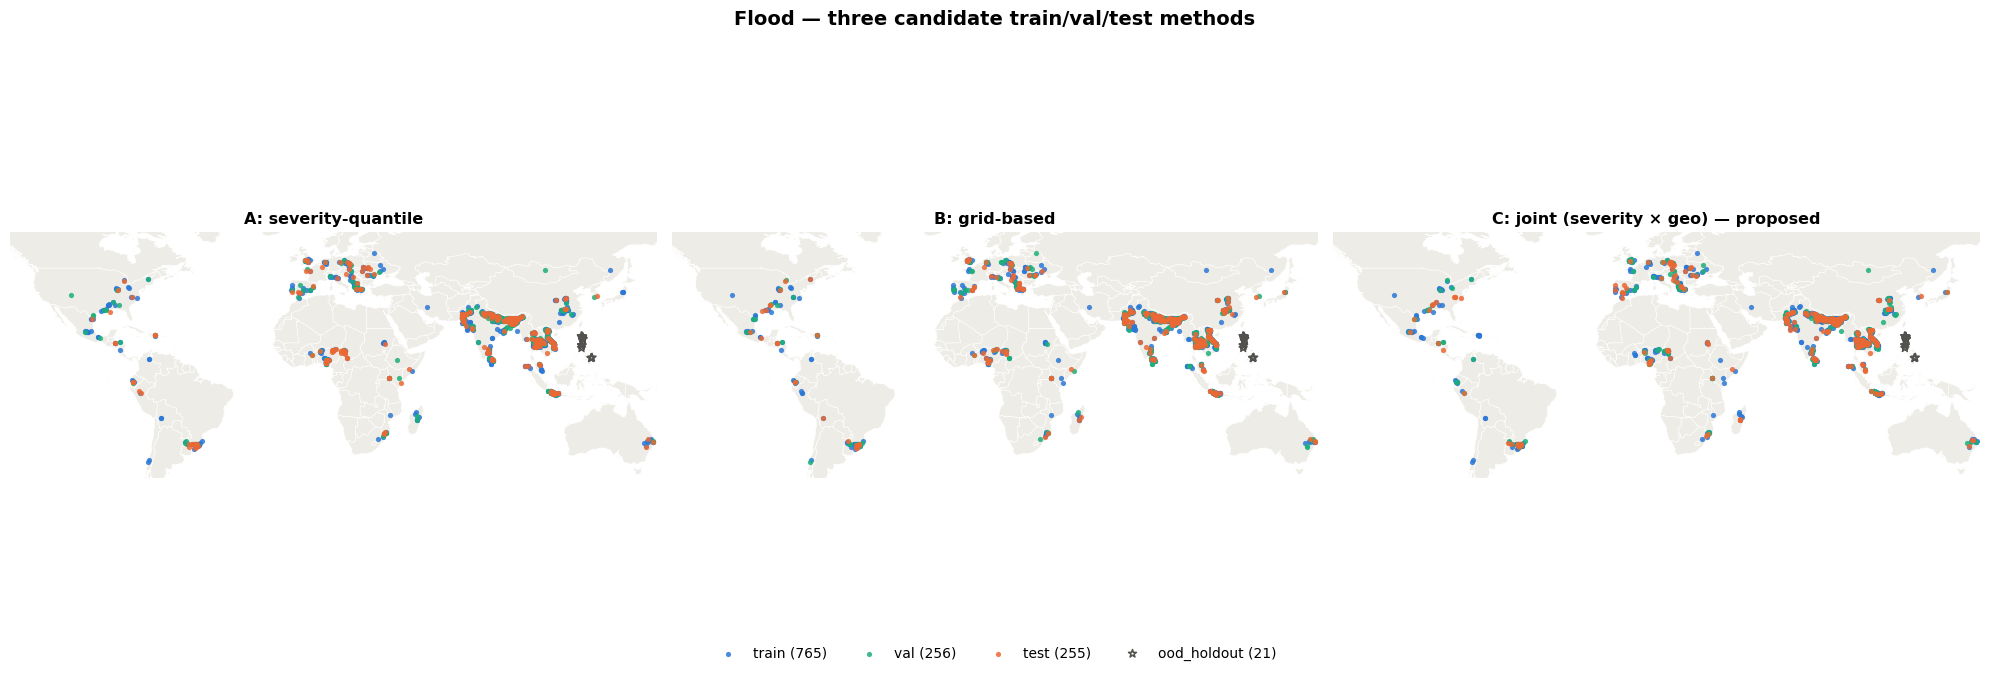

In [12]:
fig, axes = plt.subplots(1, 3, figsize=(20, 6.2))
panels = [
    ("A: severity-quantile", "split_severity"),
    ("B: grid-based", "split_grid"),
    ("C: joint (severity \u00d7 geo) \u2014 proposed", "split_joint"),
]
for ax, (title, split_c) in zip(axes, panels):
    basemap(ax)
    for sp, color in SPLIT_COLOR.items():
        sub = events[events[split_c] == sp]
        ax.scatter(sub["centroid_lon"], sub["centroid_lat"], s=14, color=color, alpha=0.85, linewidth=0, zorder=3, label=f"{sp} ({len(sub)})")
    ood = events[events[split_c] == "ood_holdout"]
    ax.scatter(ood["centroid_lon"], ood["centroid_lat"], s=36, facecolor="none", edgecolor=OOD_COLOR, linewidth=1.1, marker="*", zorder=4, label=f"ood_holdout ({len(ood)})")
    ax.set_title(title, fontsize=11.5, fontweight="bold")
handles, labels = axes[0].get_legend_handles_labels()
fig.legend(handles, labels, loc="lower center", ncol=4, frameon=False, fontsize=10, bbox_to_anchor=(0.5, -0.04))
fig.suptitle("Flood \u2014 three candidate train/val/test methods", fontsize=14, fontweight="bold", y=1.03)
fig.tight_layout()
fig.savefig(f"{OUTPUT_DIR}/03_three_way_split_map.png", dpi=200, bbox_inches="tight", facecolor="white")
plt.show()

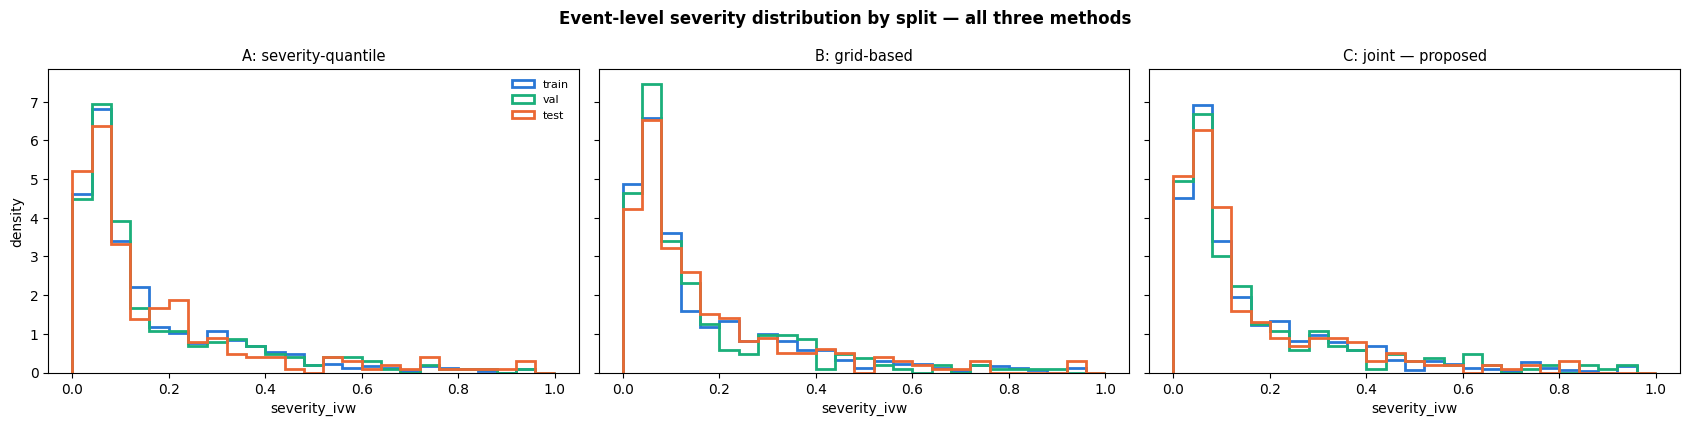

In [13]:
fig, axes = plt.subplots(1, 3, figsize=(17, 4.3), sharey=True)
panels_sev = [
    ("A: severity-quantile", "split_severity"),
    ("B: grid-based", "split_grid"),
    ("C: joint \u2014 proposed", "split_joint"),
]
for ax, (title, split_c) in zip(axes, panels_sev):
    for sp, color in SPLIT_COLOR.items():
        vals = events[events[split_c] == sp]["severity_ivw"].dropna()
        ax.hist(vals, bins=25, range=(0, 1), histtype="step", linewidth=2, color=color, label=sp, density=True)
    ax.set_title(title, fontsize=10.5); ax.set_xlabel("severity_ivw")
axes[0].set_ylabel("density"); axes[0].legend(frameon=False, fontsize=8)
fig.suptitle("Event-level severity distribution by split \u2014 all three methods", fontsize=12, fontweight="bold")
fig.tight_layout()
fig.savefig(f"{OUTPUT_DIR}/04_severity_by_split_3way.png", dpi=200, bbox_inches="tight", facecolor="white")
plt.show()

In [14]:
def wasserstein1d(a, b, n=1000):
    a = np.sort(np.asarray(a, float)); b = np.sort(np.asarray(b, float))
    if len(a) == 0 or len(b) == 0: return np.nan
    q = np.linspace(0, 1, n)
    return float(np.mean(np.abs(np.quantile(a, q) - np.quantile(b, q))))

METHODS = [
    ("A: severity-quantile", "split_severity"),
    ("B: grid", "split_grid"),
    ("C: joint (severity x geo)", "split_joint"),
]
rows = []
for name, split_c in METHODS:
    parts_sev = {sp: events[events[split_c] == sp]["severity_ivw"].values for sp in ("train", "val", "test")}
    parts_lon = {sp: events[events[split_c] == sp]["centroid_lon"].values for sp in ("train", "val", "test")}
    parts_lat = {sp: events[events[split_c] == sp]["centroid_lat"].values for sp in ("train", "val", "test")}
    rows.append(dict(
        method=name,
        severity_wass_tr_te=wasserstein1d(parts_sev["train"], parts_sev["test"]),
        severity_wass_tr_va=wasserstein1d(parts_sev["train"], parts_sev["val"]),
        lon_wass_tr_te=wasserstein1d(parts_lon["train"], parts_lon["test"]),
        lon_wass_tr_va=wasserstein1d(parts_lon["train"], parts_lon["val"]),
        lat_wass_tr_te=wasserstein1d(parts_lat["train"], parts_lat["test"]),
        lat_wass_tr_va=wasserstein1d(parts_lat["train"], parts_lat["val"]),
    ))
balance = pd.DataFrame(rows).set_index("method")
balance.round(4)

,severity_wass_tr_te,severity_wass_tr_va,lon_wass_tr_te,lon_wass_tr_va,lat_wass_tr_te,lat_wass_tr_va
method,,,,,,
A: severity-quantile,0.0157,0.0072,5.5438,2.5879,2.9548,1.1942
B: grid,0.0085,0.0142,1.9550,1.3478,0.4468,0.6018
C: joint (severity x geo),0.0070,0.0113,1.7915,1.5363,0.8751,1.0929


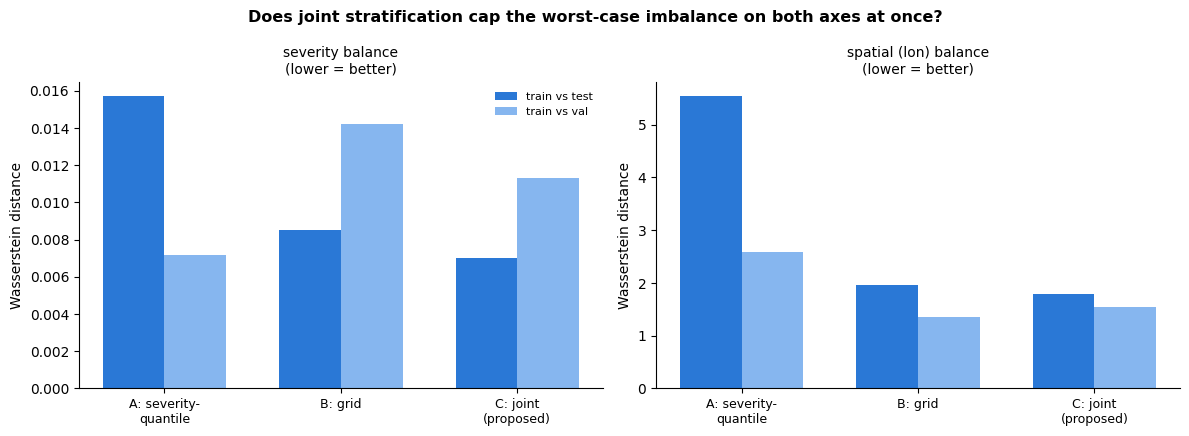

In [15]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4.4))
x = np.arange(3); width = 0.35
method_labels = ["A: severity-\nquantile", "B: grid", "C: joint\n(proposed)"]
for ax, cols, title in [
    (axes[0], ["severity_wass_tr_te", "severity_wass_tr_va"], "severity balance\n(lower = better)"),
    (axes[1], ["lon_wass_tr_te", "lon_wass_tr_va"], "spatial (lon) balance\n(lower = better)"),
]:
    ax.bar(x - width / 2, balance[cols[0]], width, color="#2a78d6", label="train vs test")
    ax.bar(x + width / 2, balance[cols[1]], width, color="#86b6ef", label="train vs val")
    ax.set_xticks(x); ax.set_xticklabels(method_labels, fontsize=9)
    ax.set_title(title, fontsize=10); ax.set_ylabel("Wasserstein distance")
    for s in ["top", "right"]: ax.spines[s].set_visible(False)
axes[0].legend(frameon=False, fontsize=8)
fig.suptitle("Does joint stratification cap the worst-case imbalance on both axes at once?", fontsize=11.5, fontweight="bold")
fig.tight_layout()
fig.savefig(f"{OUTPUT_DIR}/05_balance_tradeoff_3way.png", dpi=200, bbox_inches="tight", facecolor="white")
plt.show()

## Per-joint-stratum composition — confirms 60:20:20 holds within every stratum

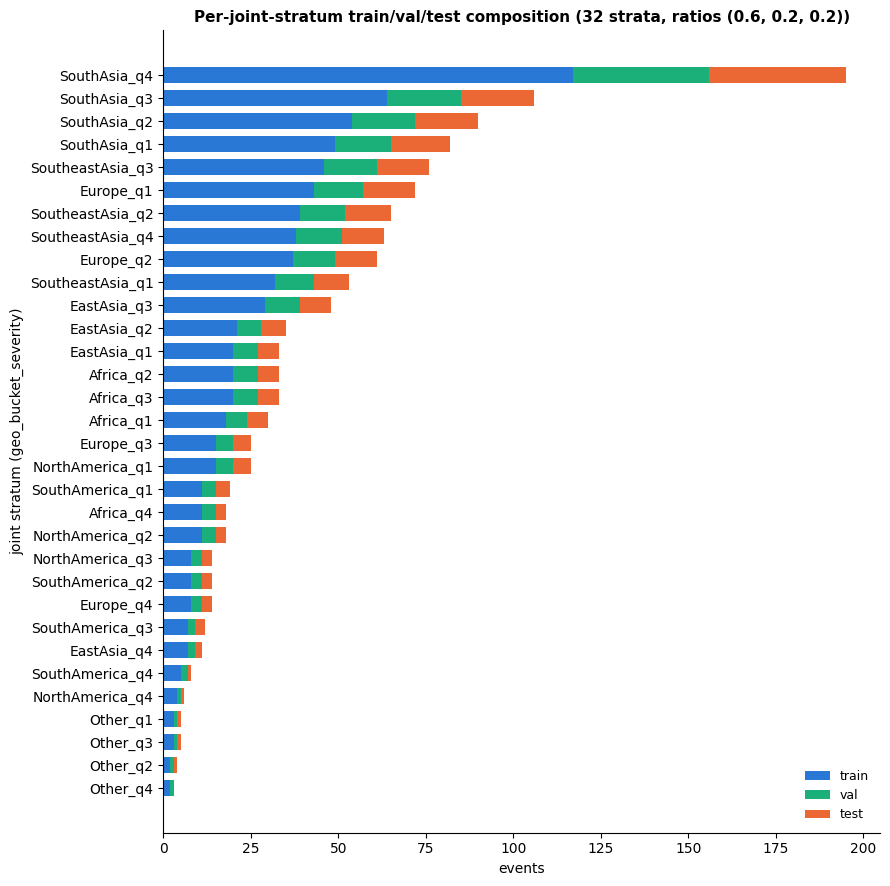

In [16]:
comp = (dev_j.assign(split=dev_j["event_id"].map(event_split_joint))
        .groupby(["joint_stratum", "split"]).size().unstack(fill_value=0))
comp = comp.reindex(columns=["train", "val", "test"], fill_value=0)
comp["n"] = comp.sum(axis=1)
comp = comp.sort_values("n", ascending=True)

fig, ax = plt.subplots(figsize=(9, max(5, 0.28 * len(comp))))
left = np.zeros(len(comp))
for sp in ["train", "val", "test"]:
    ax.barh(comp.index.astype(str), comp[sp], left=left, color=SPLIT_COLOR[sp], label=sp, height=0.72)
    left += comp[sp].values
ax.set_xlabel("events"); ax.set_ylabel("joint stratum (geo_bucket_severity)")
ax.set_title(f"Per-joint-stratum train/val/test composition ({len(comp)} strata, ratios {RATIOS})", fontsize=11, fontweight="bold")
ax.legend(frameon=False, fontsize=9, loc="lower right")
for spine in ["top", "right"]: ax.spines[spine].set_visible(False)
fig.tight_layout()
fig.savefig(f"{OUTPUT_DIR}/06_per_stratum_composition.png", dpi=200, bbox_inches="tight", facecolor="white")
plt.show()

## Summary → `split_summary_joint.json`

In [17]:
import json
summary = {
    "seed": SEED, "ratios": list(RATIOS), "k_severity_bins": K,
    "geo_unit": GEO_UNIT, "geo_min_events": GEO_MIN_EVENTS, "n_geo_buckets": int(dev_j["geo_bucket"].nunique()),
    "n_joint_strata": int(dev_j["joint_stratum"].nunique()),
    "ood_unit": OOD_UNIT, "ood_regions": OOD_REGIONS,
    "events": {sp: int((events["split_joint"] == sp).sum()) for sp in ("train", "val", "test", "ood_holdout")},
    "chips": {sp: int((manifest_joint["split"] == sp).sum()) for sp in ("train", "val", "test", "ood_holdout")},
    "test_counts_by_geo_bucket": events[events.split_joint == "test"]["geo_bucket"].value_counts().to_dict(),
    "balance_wasserstein_3way": balance.round(4).to_dict("index"),
    "leakage_check": {"events_in_multiple_splits": leaked, "passed": len(leaked) == 0},
}
with open(f"{OUTPUT_DIR}/split_summary_joint.json", "w") as f:
    json.dump(summary, f, indent=2, default=str)
print(json.dumps(summary, indent=2, default=str))

{
  "seed": 42,
  "ratios": [
    0.6,
    0.2,
    0.2
  ],
  "k_severity_bins": 4,
  "geo_unit": "continent",
  "geo_min_events": 30,
  "n_geo_buckets": 8,
  "n_joint_strata": 32,
  "ood_unit": "country",
  "ood_regions": {
    "flooded": [
      "Philippines"
    ]
  },
  "events": {
    "train": 767,
    "val": 258,
    "test": 251,
    "ood_holdout": 21
  },
  "chips": {
    "train": 3040,
    "val": 1013,
    "test": 981,
    "ood_holdout": 68
  },
  "test_counts_by_geo_bucket": {
    "SouthAsia": 95,
    "SoutheastAsia": 50,
    "Europe": 35,
    "EastAsia": 24,
    "Africa": 21,
    "NorthAmerica": 12,
    "SouthAmerica": 11,
    "Other": 3
  },
  "balance_wasserstein_3way": {
    "A: severity-quantile": {
      "severity_wass_tr_te": 0.0157,
      "severity_wass_tr_va": 0.0072,
      "lon_wass_tr_te": 5.5438,
      "lon_wass_tr_va": 2.5879,
      "lat_wass_tr_te": 2.9548,
      "lat_wass_tr_va": 1.1942
    },
    "B: grid": {
      "severity_wass_tr_te": 0.0085,
      "severit

## How to use / next steps

1. If Method C is adopted for this hazard, re-run the equivalent of `update_split.py` with joint
   (severity × coarse-geography) strata instead of severity-only quantile bins, and `--reshard`
   against the real production dataset — this notebook's `manifest_joint.parquet` is a standalone
   comparison artifact and does not touch production.
2. To replicate for another hazard, copy this notebook and change only `INPUT_PATHS`,
   `OUD_REGIONS`/`OOD_REGIONS`, and `OUTPUT_DIR` in the CONFIG cell — everything else, including
   Method A and Method B, is computed inline and needs no pre-existing split/severity columns.